Clean dataset shape: (89, 22)
Imputed dataset shape: (100, 36)
Original features count: 22
Enhanced features count: 69
New features created: 47
Enhanced feature set saved to 'dc_housing_enhanced_features.csv'
Features with potential issues:
Empty DataFrame
Columns: [inf_count, nan_count, min, max]
Index: []


C:\Users\rding\AppData\Local\Temp\ipykernel_19872\4165568016.py:188: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '310250.5089844425' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_enhanced.at[i, 'zhvi_approx'] = base_zhvi * cumulative_factor


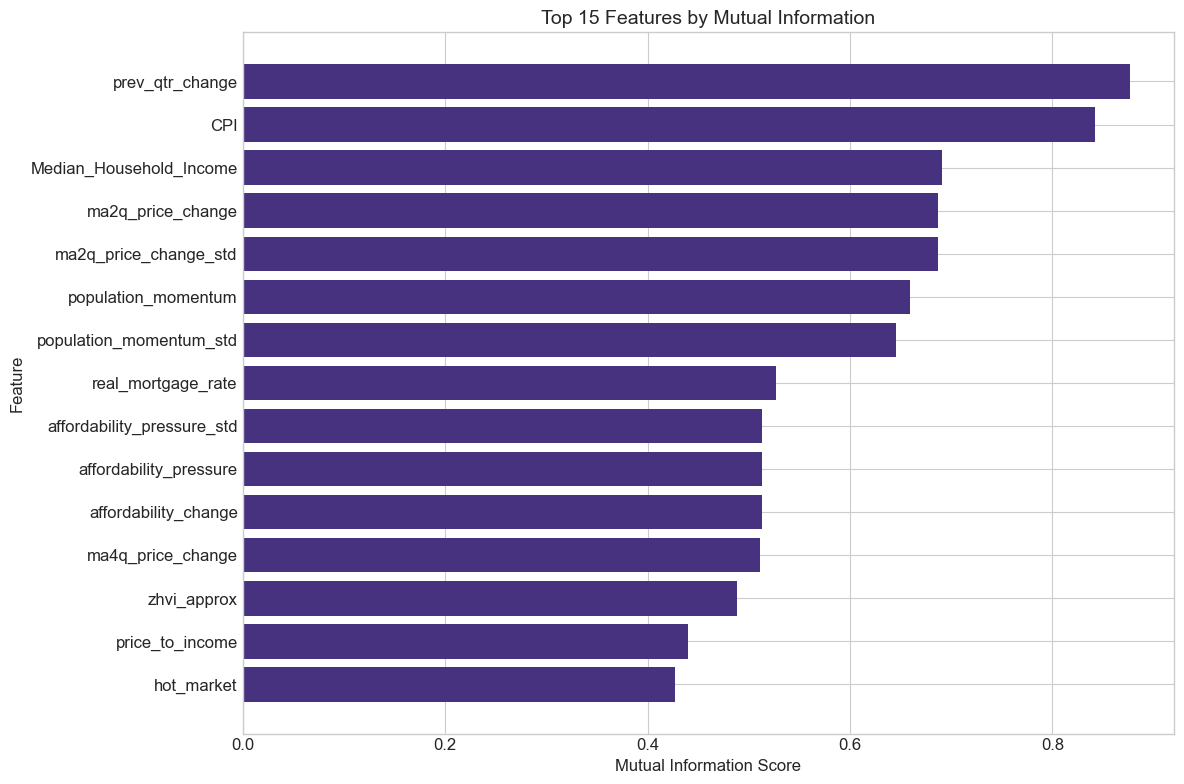

Top 15 features by mutual information:
1. prev_qtr_change: 0.8762
2. CPI: 0.8424
3. Median_Household_Income: 0.6908
4. ma2q_price_change: 0.6869
5. ma2q_price_change_std: 0.6869
6. population_momentum: 0.6590
7. population_momentum_std: 0.6455
8. real_mortgage_rate: 0.5273
9. affordability_pressure_std: 0.5132
10. affordability_pressure: 0.5132
11. affordability_change: 0.5132
12. ma4q_price_change: 0.5106
13. zhvi_approx: 0.4880
14. price_to_income: 0.4396
15. hot_market: 0.4266


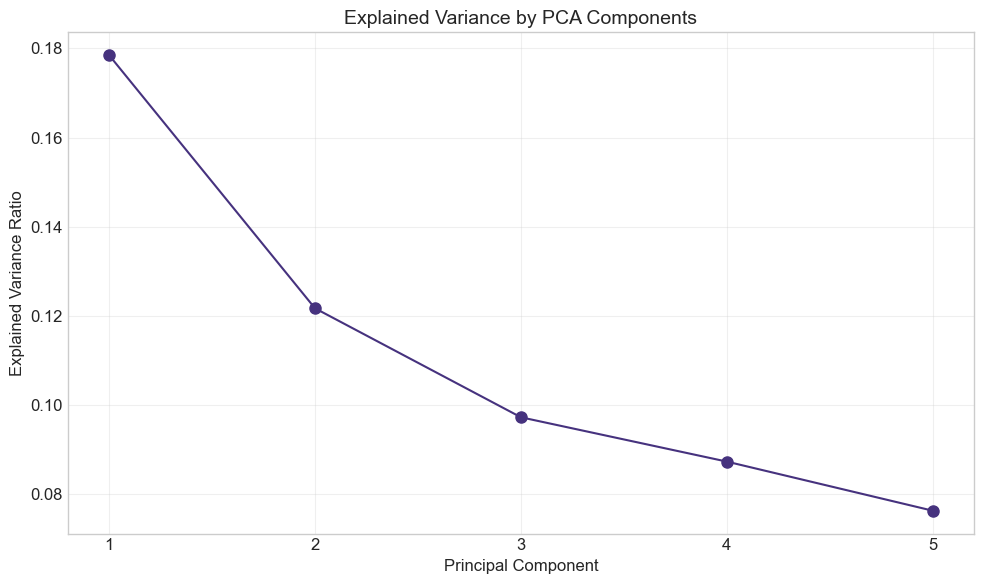

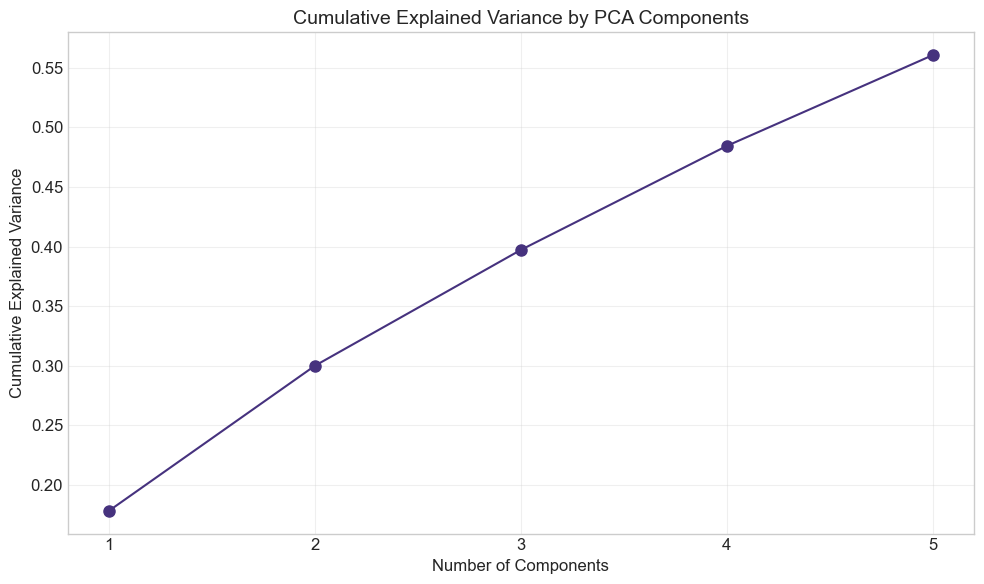

PCA results:
Component 1: 0.1785 of variance explained
Component 2: 0.1216 of variance explained
Component 3: 0.0971 of variance explained
Component 4: 0.0872 of variance explained
Component 5: 0.0761 of variance explained
Total variance explained: 0.5606


<Figure size 1200x800 with 0 Axes>

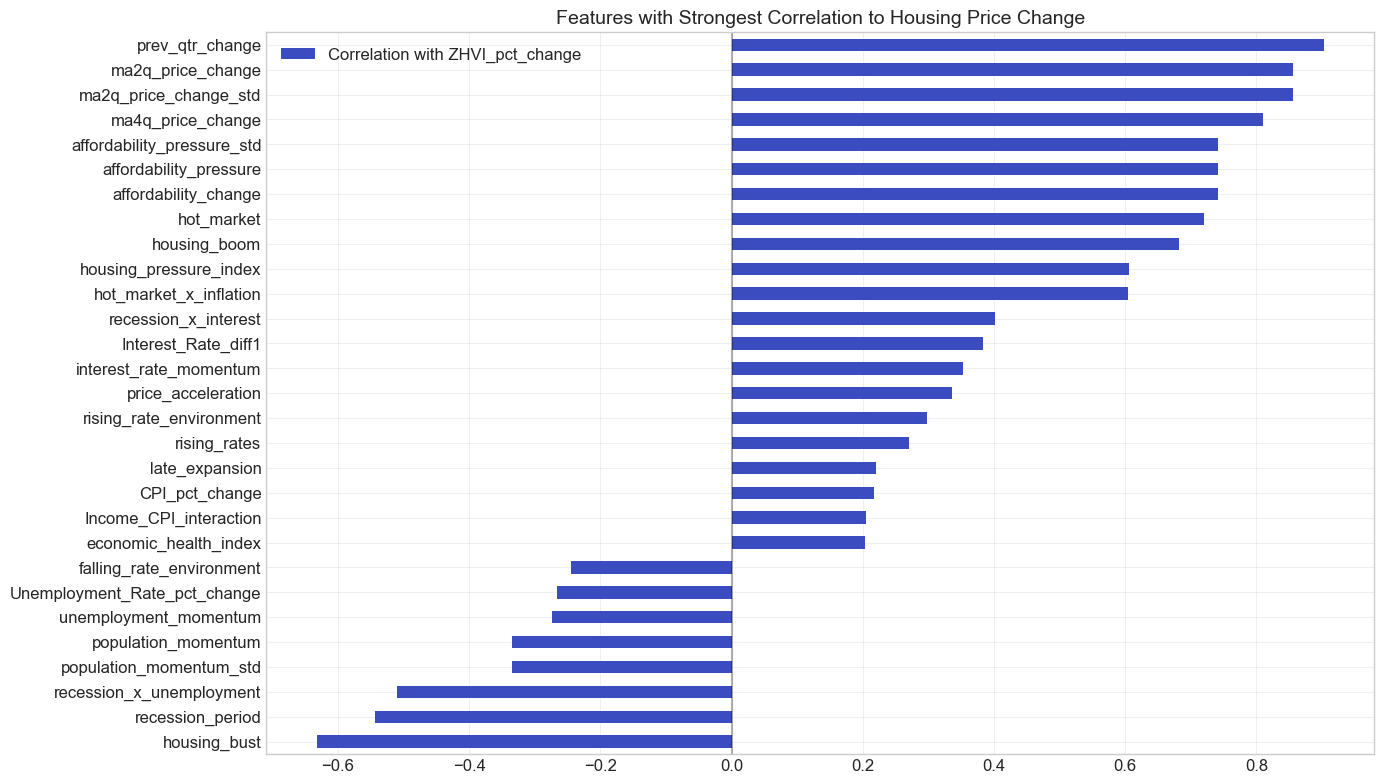

Top correlations with housing price change:
                              Correlation with ZHVI_pct_change
prev_qtr_change                                       0.902553
ma2q_price_change                                     0.855256
ma2q_price_change_std                                 0.855256
ma4q_price_change                                     0.810301
affordability_pressure_std                            0.741382
affordability_change                                  0.741382
affordability_pressure                                0.741382
hot_market                                            0.719833
housing_boom                                          0.681695
housing_pressure_index                                0.605713
hot_market_x_inflation                                0.603988
recession_x_interest                                  0.400839
Interest_Rate_diff1                                   0.383959
interest_rate_momentum                                0.353475
price_accel

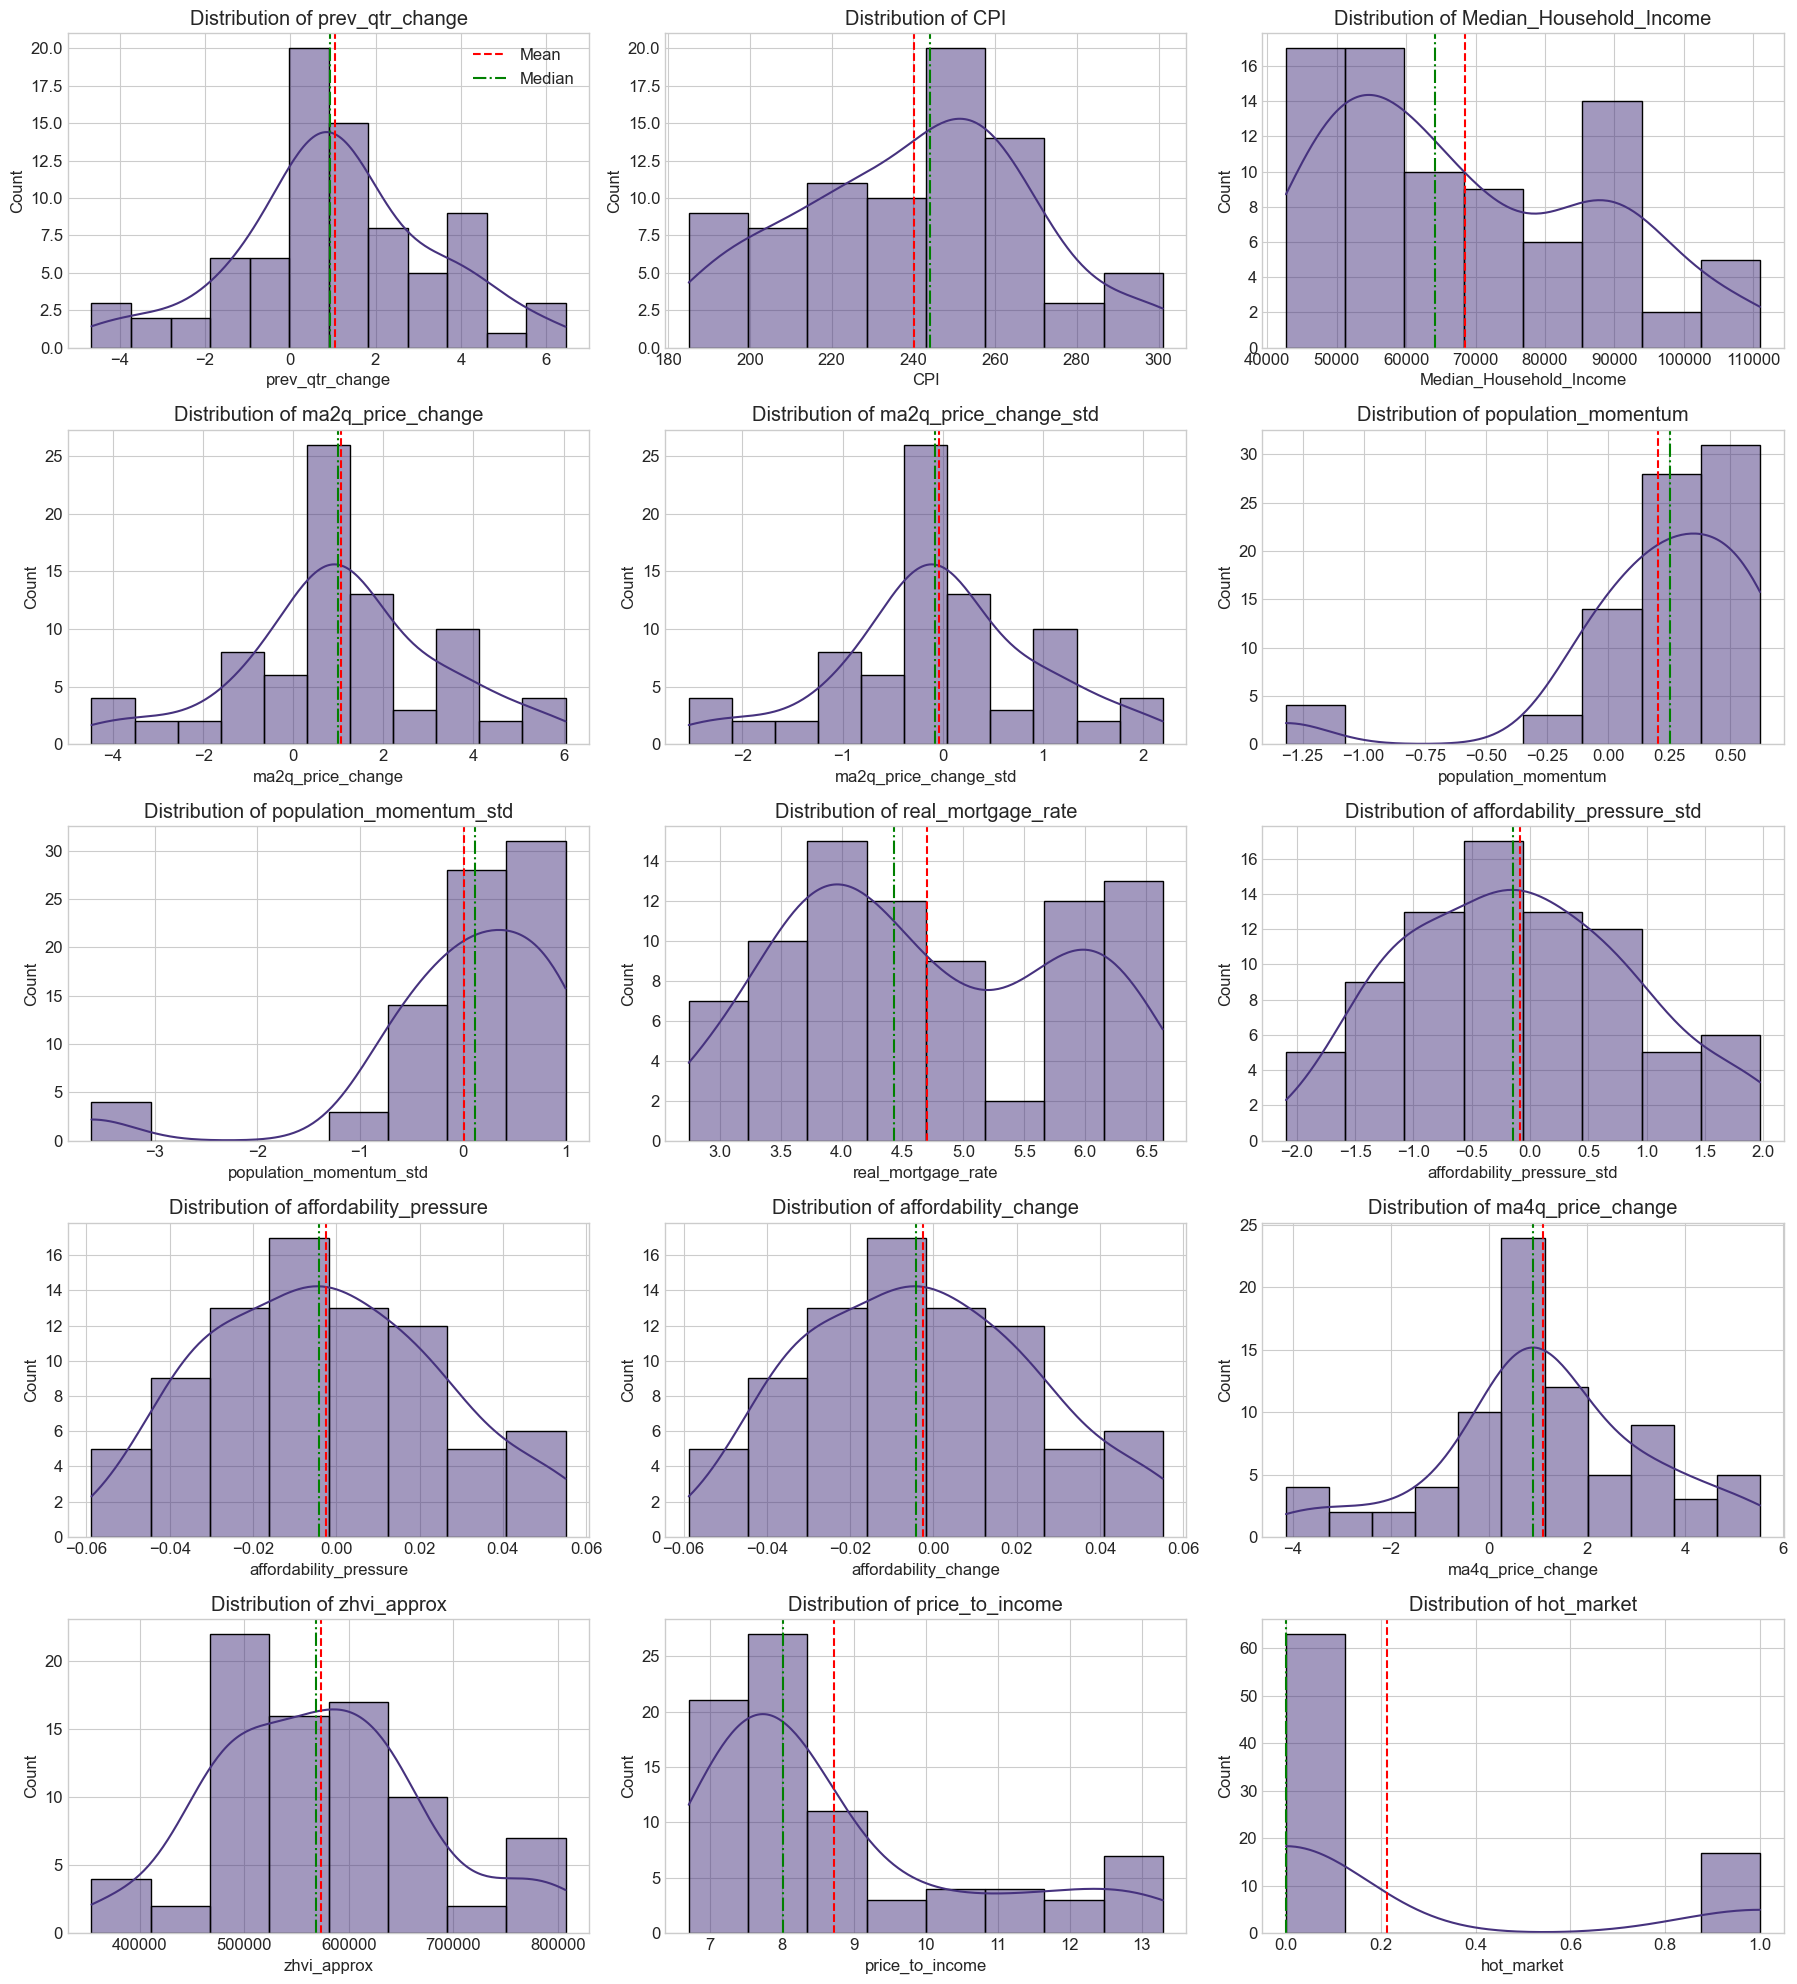

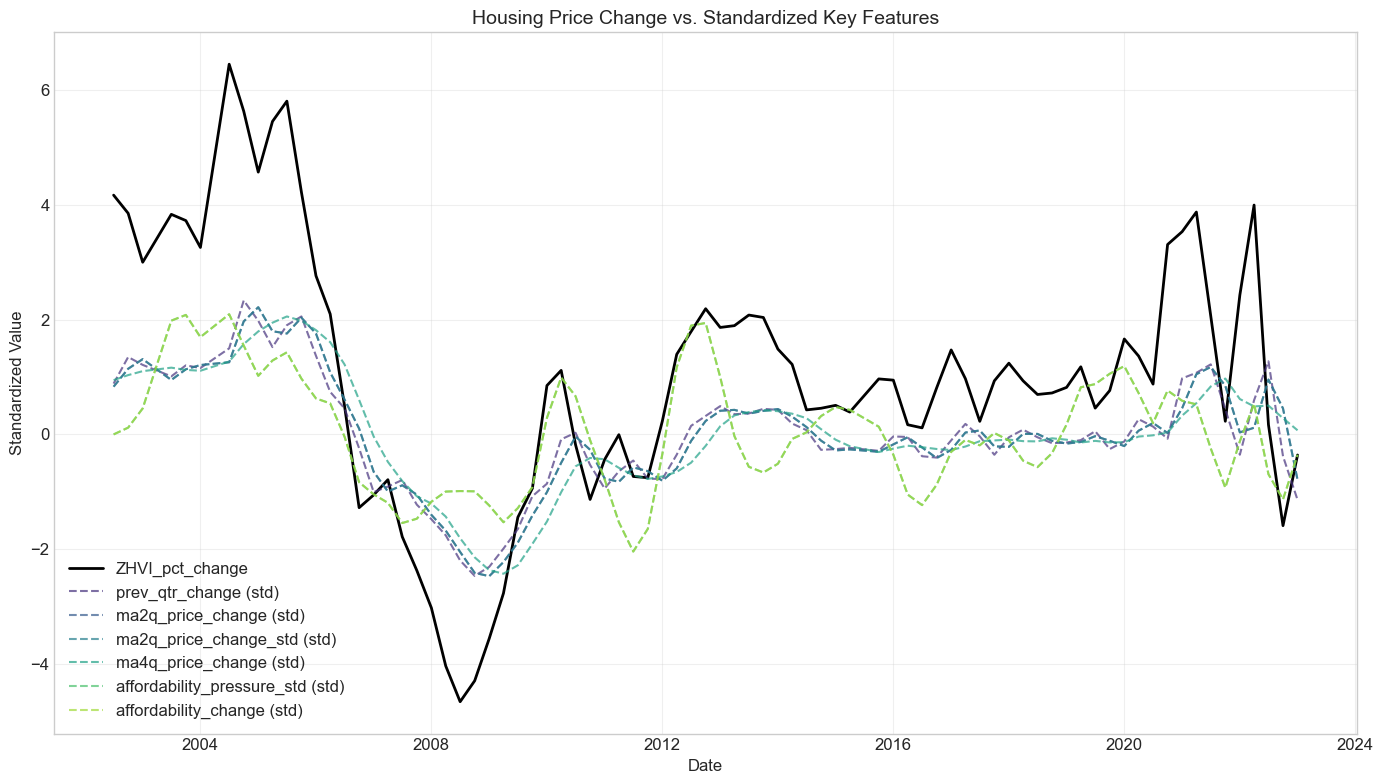

Final selected feature set saved to 'dc_housing_selected_features.csv'

Enhanced feature engineering complete!
Total features in enhanced set: 69
Selected features for modeling: 20
Final dataset shape: (80, 21)


In [7]:
# DC Housing Market Feature Engineering
# This script creates enhanced features for the DC housing market prediction model

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression, SelectKBest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Set visualization styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

# -------------------------------------------------------------
# 1. Load Data and Create Base Features
# -------------------------------------------------------------

def load_data():
    """Load the dataset and return both clean and partial versions"""
    df_clean = pd.read_csv('dc_housing_modeling_features_clean.csv', parse_dates=['Date'], index_col='Date')
    df_partial = pd.read_csv('dc_housing_modeling_features_partial.csv', parse_dates=['Date'], index_col='Date')
    
    print(f"Clean dataset shape: {df_clean.shape}")
    print(f"Imputed dataset shape: {df_partial.shape}")
    
    return df_clean, df_partial

def create_market_regime_features(df):
    """Create more specific market regime indicators"""
    # Copy the dataframe to avoid modifying the original
    df_enhanced = df.copy()
    
    # 1. Interest rate environment indicators
    # Rising rate environment (more specific than the existing rising_rates)
    df_enhanced['rising_rate_environment'] = ((df_enhanced.index >= '2004-06-01') & (df_enhanced.index <= '2006-06-30')).astype(int) | \
                                           ((df_enhanced.index >= '2015-12-01') & (df_enhanced.index <= '2018-12-31')).astype(int) | \
                                           ((df_enhanced.index >= '2022-03-01')).astype(int)
    
    # Falling rate environment
    df_enhanced['falling_rate_environment'] = ((df_enhanced.index >= '2001-01-01') & (df_enhanced.index <= '2003-06-30')).astype(int) | \
                                            ((df_enhanced.index >= '2007-09-01') & (df_enhanced.index <= '2008-12-31')).astype(int) | \
                                            ((df_enhanced.index >= '2019-06-01') & (df_enhanced.index <= '2020-03-31')).astype(int)
    
    # Zero lower bound period
    df_enhanced['zero_rate_environment'] = ((df_enhanced.index >= '2009-01-01') & (df_enhanced.index <= '2015-11-30')).astype(int) | \
                                         ((df_enhanced.index >= '2020-04-01') & (df_enhanced.index <= '2022-02-28')).astype(int)
    
    # 2. Housing market specific phases
    # Housing boom phase (strong appreciation)
    df_enhanced['housing_boom'] = ((df_enhanced.index >= '2002-01-01') & (df_enhanced.index <= '2006-04-30')).astype(int) | \
                                ((df_enhanced.index >= '2020-06-01') & (df_enhanced.index <= '2022-01-31')).astype(int)
    
    # Housing bust phase (price declines)
    df_enhanced['housing_bust'] = ((df_enhanced.index >= '2006-05-01') & (df_enhanced.index <= '2009-05-31')).astype(int)
    
    # Recovery phase (moderate growth after declines)
    df_enhanced['housing_recovery'] = ((df_enhanced.index >= '2009-06-01') & (df_enhanced.index <= '2013-12-31')).astype(int)
    
    # Stable growth phase
    df_enhanced['housing_stable_growth'] = ((df_enhanced.index >= '2014-01-01') & (df_enhanced.index <= '2019-12-31')).astype(int)
    
    # Post-pandemic adjustment
    df_enhanced['post_pandemic_adjustment'] = ((df_enhanced.index >= '2022-02-01')).astype(int)
    
    # 3. Economic cycle phases
    # Early expansion
    df_enhanced['early_expansion'] = ((df_enhanced.index >= '2002-01-01') & (df_enhanced.index <= '2003-12-31')).astype(int) | \
                                   ((df_enhanced.index >= '2009-07-01') & (df_enhanced.index <= '2011-12-31')).astype(int) | \
                                   ((df_enhanced.index >= '2020-07-01') & (df_enhanced.index <= '2021-12-31')).astype(int)
    
    # Late expansion
    df_enhanced['late_expansion'] = ((df_enhanced.index >= '2004-01-01') & (df_enhanced.index <= '2007-11-30')).astype(int) | \
                                  ((df_enhanced.index >= '2012-01-01') & (df_enhanced.index <= '2019-12-31')).astype(int) | \
                                  ((df_enhanced.index >= '2022-01-01')).astype(int)
    
    return df_enhanced

def create_interaction_features(df):
    """Create interaction terms between key variables"""
    df_enhanced = df.copy()
    
    # 1. Interest rate and mortgage rate interactions
    # Interest rate impacts on housing affordability
    df_enhanced['interest_x_mortgage'] = df_enhanced['Interest_Rate_diff1'] * df_enhanced['Mortgage_Rate_diff1']
    
    # 2. Economic indicator interactions
    # Unemployment and GDP interaction (economic health)
    if 'Unemployment_Rate' in df_enhanced.columns and 'GDP_Growth' in df_enhanced.columns:
        df_enhanced['unemployment_x_gdp'] = df_enhanced['Unemployment_Rate'] * df_enhanced['GDP_Growth']
    
    # 3. Interactions with pandemic period
    if 'pandemic_period' in df_enhanced.columns:
        # Pandemic effects on key economic variables
        if 'Unemployment_Rate' in df_enhanced.columns:
            df_enhanced['pandemic_x_unemployment'] = df_enhanced['pandemic_period'] * df_enhanced['Unemployment_Rate']
        
        if 'Interest_Rate_diff1' in df_enhanced.columns:
            df_enhanced['pandemic_x_interest'] = df_enhanced['pandemic_period'] * df_enhanced['Interest_Rate_diff1']
        
        if 'Mortgage_Rate_diff1' in df_enhanced.columns:
            df_enhanced['pandemic_x_mortgage'] = df_enhanced['pandemic_period'] * df_enhanced['Mortgage_Rate_diff1']
    
    # 4. Interactions with recession periods
    if 'recession_period' in df_enhanced.columns:
        # Recession effects on key economic variables
        if 'Unemployment_Rate' in df_enhanced.columns:
            df_enhanced['recession_x_unemployment'] = df_enhanced['recession_period'] * df_enhanced['Unemployment_Rate']
        
        if 'Interest_Rate_diff1' in df_enhanced.columns:
            df_enhanced['recession_x_interest'] = df_enhanced['recession_period'] * df_enhanced['Interest_Rate_diff1']
    
    # 5. Hot market interactions
    if 'hot_market' in df_enhanced.columns:
        # Hot market effects on key economic variables
        if 'Mortgage_Rate_diff1' in df_enhanced.columns:
            df_enhanced['hot_market_x_mortgage'] = df_enhanced['hot_market'] * df_enhanced['Mortgage_Rate_diff1']
        
        if 'CPI_pct_change' in df_enhanced.columns:
            df_enhanced['hot_market_x_inflation'] = df_enhanced['hot_market'] * df_enhanced['CPI_pct_change']
    
    return df_enhanced

def create_lag_and_momentum_features(df):
    """Create lagged features and momentum indicators"""
    df_enhanced = df.copy()
    
    # Target variable is ZHVI_pct_change
    if 'ZHVI_pct_change' in df_enhanced.columns:
        # 1. Create price momentum features
        # Previous quarter momentum
        df_enhanced['prev_qtr_change'] = df_enhanced['ZHVI_pct_change'].shift(1)
        
        # Moving averages of price changes (2-quarter and 4-quarter)
        df_enhanced['ma2q_price_change'] = df_enhanced['ZHVI_pct_change'].rolling(window=2).mean().shift(1)
        df_enhanced['ma4q_price_change'] = df_enhanced['ZHVI_pct_change'].rolling(window=4).mean().shift(1)
        
        # Price acceleration (change in rate of change)
        df_enhanced['price_acceleration'] = df_enhanced['ZHVI_pct_change'].diff().shift(1)
        
        # 2. Price volatility
        df_enhanced['price_volatility'] = df_enhanced['ZHVI_pct_change'].rolling(window=4).std().shift(1)
        
        # 3. Trend strength (ratio of current change to average past changes)
        df_enhanced['trend_strength'] = df_enhanced['ZHVI_pct_change'] / df_enhanced['ma4q_price_change'].shift(1)
    
    # 4. Economic indicator momentum
    # Interest rate momentum
    if 'Interest_Rate_diff1' in df_enhanced.columns:
        df_enhanced['interest_rate_momentum'] = df_enhanced['Interest_Rate_diff1'].rolling(window=2).mean().shift(1)
        df_enhanced['interest_rate_acceleration'] = df_enhanced['Interest_Rate_diff1'].diff().shift(1)
    
    # Unemployment rate momentum
    if 'Unemployment_Rate' in df_enhanced.columns:
        df_enhanced['unemployment_momentum'] = df_enhanced['Unemployment_Rate'].diff().shift(1)
    
    # CPI momentum
    if 'CPI_pct_change' in df_enhanced.columns:
        df_enhanced['inflation_momentum'] = df_enhanced['CPI_pct_change'].diff().shift(1)
    
    return df_enhanced

def create_affordability_features(df):
    """Create housing affordability metrics"""
    df_enhanced = df.copy()
    
    # 1. Price-to-income ratio (if not already present)
    if 'price_to_income' not in df_enhanced.columns and 'Median_Household_Income' in df_enhanced.columns:
        # We need to recreate ZHVI from ZHVI_pct_change for a proper ratio
        # If you have ZHVI directly, use that instead
        # This is a rough approximation
        base_zhvi = 300000  # Starting ZHVI value (approximate)
        
        if 'ZHVI_pct_change' in df_enhanced.columns:
            # Convert percent changes to a price series
            df_enhanced['zhvi_approx'] = 0
            cumulative_factor = 1
            
            for i, row in df_enhanced.iterrows():
                if i == df_enhanced.index[0]:
                    df_enhanced.at[i, 'zhvi_approx'] = base_zhvi
                else:
                    pct_change = row['ZHVI_pct_change'] / 100
                    cumulative_factor *= (1 + pct_change)
                    df_enhanced.at[i, 'zhvi_approx'] = base_zhvi * cumulative_factor
            
            # Now create the price-to-income ratio
            df_enhanced['price_to_income'] = df_enhanced['zhvi_approx'] / df_enhanced['Median_Household_Income']
            
            # Track change in affordability
            df_enhanced['affordability_change'] = df_enhanced['price_to_income'].pct_change()
    
    # 2. Real mortgage rates (adjusted for inflation)
    if 'Mortgage_Rate_diff1' in df_enhanced.columns and 'CPI_pct_change' in df_enhanced.columns:
        # Calculate real mortgage rate changes
        df_enhanced['real_mortgage_rate_change'] = df_enhanced['Mortgage_Rate_diff1'] - (df_enhanced['CPI_pct_change'] / 100)
    
    # 3. Mortgage payment burden (as % of income)
    if 'Mortgage_Rate_diff1' in df_enhanced.columns and 'zhvi_approx' in df_enhanced.columns and 'Median_Household_Income' in df_enhanced.columns:
        # Approximate monthly payment on median home (rough calculation)
        df_enhanced['mortgage_payment_pct_income'] = (df_enhanced['zhvi_approx'] * 0.8 * (df_enhanced['Mortgage_Rate_diff1'] / 12)) / (df_enhanced['Median_Household_Income'] / 12) * 100
    
    return df_enhanced

def create_demographic_features(df):
    """Create enhanced demographic features"""
    df_enhanced = df.copy()
    
    # 1. Population density trend
    if 'Population_pct_change' in df_enhanced.columns:
        df_enhanced['population_momentum'] = df_enhanced['Population_pct_change'].rolling(window=4).mean().shift(1)
    
    # 2. Socioeconomic indicators
    if 'Poverty_Rate_lag5' in df_enhanced.columns and 'Median_Household_Income_pct_change' in df_enhanced.columns:
        # SAFER APPROACH: Avoid division by very small numbers
        # Create a masked version of income change with small values replaced by NaN
        income_change_safe = df_enhanced['Median_Household_Income_pct_change'].copy()
        # Replace values close to zero with NaN to avoid extreme ratios
        income_change_safe[abs(income_change_safe) < 0.1] = np.nan
        
        # Calculate the ratio where income change is not too small
        df_enhanced['socioeconomic_change'] = df_enhanced['Poverty_Rate_lag5'] / income_change_safe
        
        # Cap extreme values to prevent outliers
        upper_limit = df_enhanced['socioeconomic_change'].quantile(0.95)
        lower_limit = df_enhanced['socioeconomic_change'].quantile(0.05)
        
        df_enhanced['socioeconomic_change'] = df_enhanced['socioeconomic_change'].clip(lower_limit, upper_limit)
    
    return df_enhanced

# -------------------------------------------------------------
# 2. Feature Selection
# -------------------------------------------------------------


def select_features_mutual_info(X, y, k=15):
    """Select top k features using mutual information"""
    # Fix: Replace inf values and handle extremely large numbers
    X_clean = X.copy()
    
    # Replace inf values with NaN first
    X_clean = X_clean.replace([np.inf, -np.inf], np.nan)
    
    # Check which columns have NaN values
    cols_with_nan = X_clean.columns[X_clean.isna().any()].tolist()
    if cols_with_nan:
        print(f"Columns with NaN or inf values: {cols_with_nan}")
        
        # For each problematic column, replace NaN with mean or median of finite values
        for col in cols_with_nan:
            finite_values = X_clean[col].dropna()
            if len(finite_values) > 0:
                X_clean[col] = X_clean[col].fillna(finite_values.median())
            else:
                # If all values are NaN/inf, drop the column
                print(f"Dropping column {col} - all values are NaN/inf")
                X_clean = X_clean.drop(col, axis=1)
    
    # Calculate mutual information
    mi_scores = mutual_info_regression(X_clean, y)
    mi_scores = pd.Series(mi_scores, index=X_clean.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    
    # Select top k features
    selected_features = mi_scores.index[:k].tolist()
    
    # Plot feature importance
    plt.figure(figsize=(12, 8))
    plt.barh(mi_scores.index[:k], mi_scores.values[:k])
    plt.title('Top 15 Features by Mutual Information', fontsize=14)
    plt.xlabel('Mutual Information Score', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.gca().invert_yaxis()  # Display features from top to bottom
    plt.tight_layout()
    plt.savefig('outputs/mutual_info_feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Top 15 features by mutual information:")
    for i, (feature, score) in enumerate(zip(mi_scores.index[:k], mi_scores.values[:k])):
        print(f"{i+1}. {feature}: {score:.4f}")
    
    return selected_features, mi_scores

def create_pca_features(X, n_components=5):
    """Create PCA features from the original feature set"""
    # Scale the data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Apply PCA
    pca = PCA(n_components=n_components)
    pca_features = pca.fit_transform(X_scaled)
    
    # Create DataFrame with PCA features
    pca_df = pd.DataFrame(
        pca_features,
        columns=[f'pca_component_{i+1}' for i in range(n_components)],
        index=X.index
    )
    
    # Plot explained variance
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, n_components+1), pca.explained_variance_ratio_, 'o-', markersize=8)
    plt.title('Explained Variance by PCA Components', fontsize=14)
    plt.xlabel('Principal Component', fontsize=12)
    plt.ylabel('Explained Variance Ratio', fontsize=12)
    plt.xticks(range(1, n_components+1))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('outputs/pca_explained_variance.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Plot cumulative explained variance
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, n_components+1), np.cumsum(pca.explained_variance_ratio_), 'o-', markersize=8)
    plt.title('Cumulative Explained Variance by PCA Components', fontsize=14)
    plt.xlabel('Number of Components', fontsize=12)
    plt.ylabel('Cumulative Explained Variance', fontsize=12)
    plt.xticks(range(1, n_components+1))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('outputs/pca_cumulative_variance.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"PCA results:")
    for i in range(n_components):
        print(f"Component {i+1}: {pca.explained_variance_ratio_[i]:.4f} of variance explained")
    print(f"Total variance explained: {np.sum(pca.explained_variance_ratio_):.4f}")
    
    return pca_df, pca

# -------------------------------------------------------------
# 3. Feature Analysis and Visualization
# -------------------------------------------------------------

def analyze_feature_correlations(df):
    """Analyze correlations between features and target"""
    # Separate target variable
    target = 'ZHVI_pct_change'
    y = df[target]
    X = df.drop(target, axis=1)
    
    # Calculate correlations with target
    correlations = pd.DataFrame(X.corrwith(y).sort_values(ascending=False))
    correlations.columns = ['Correlation with ZHVI_pct_change']
    
    # Filter out weak correlations for readability
    strong_correlations = correlations[abs(correlations['Correlation with ZHVI_pct_change']) > 0.2]
    
    # Plot top positive and negative correlations
    plt.figure(figsize=(12, 8))
    strong_correlations.sort_values('Correlation with ZHVI_pct_change').plot(
        kind='barh', color=plt.cm.coolwarm(np.linspace(0, 1, len(strong_correlations)))
    )
    plt.title('Features with Strongest Correlation to Housing Price Change', fontsize=14)
    plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('outputs/feature_correlations.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Top correlations with housing price change:")
    print(strong_correlations.to_string())
    
    return strong_correlations

def plot_feature_distributions(df, selected_features):
    """Plot distributions of selected features"""
    n_features = len(selected_features)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
    axes = axes.flatten()
    
    for i, feature in enumerate(selected_features):
        if i < len(axes):
            sns.histplot(df[feature], kde=True, ax=axes[i])
            axes[i].set_title(f'Distribution of {feature}')
            axes[i].axvline(df[feature].mean(), color='red', linestyle='--', label='Mean')
            axes[i].axvline(df[feature].median(), color='green', linestyle='-.', label='Median')
            
            if i == 0:
                axes[i].legend()
    
    # Hide unused subplots
    for j in range(n_features, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.savefig('outputs/feature_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_feature_time_series(df, selected_features, max_features=6):
    """Plot time series of selected features"""
    # If there are too many features, select a subset
    if len(selected_features) > max_features:
        features_to_plot = selected_features[:max_features]
    else:
        features_to_plot = selected_features
    
    plt.figure(figsize=(14, 8))
    
    # Plot target variable
    plt.plot(df.index, df['ZHVI_pct_change'], 'k-', linewidth=2, label='ZHVI_pct_change')
    
    # Plot selected features
    for feature in features_to_plot:
        if feature != 'ZHVI_pct_change':
            # Standardize the feature for easier comparison
            std_feature = (df[feature] - df[feature].mean()) / df[feature].std()
            plt.plot(df.index, std_feature, '--', alpha=0.7, label=f'{feature} (std)')
    
    plt.title('Housing Price Change vs. Standardized Key Features', fontsize=14)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Standardized Value', fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('outputs/feature_time_series.png', dpi=300, bbox_inches='tight')
    plt.show()

# -------------------------------------------------------------
# 4. Main Feature Engineering Function
# -------------------------------------------------------------

def create_enhanced_feature_set():
    """Create a complete enhanced feature set for modeling"""
    # 1. Load data
    df_clean, df_partial = load_data()
    
    # 2. Apply feature engineering to clean dataset
    df_enhanced = df_clean.copy()
    
    # Add market regime features
    df_enhanced = create_market_regime_features(df_enhanced)
    
    # Add interaction features
    df_enhanced = create_interaction_features(df_enhanced)
    
    # Add lag and momentum features
    df_enhanced = create_lag_and_momentum_features(df_enhanced)
    
    # Add affordability features
    df_enhanced = create_affordability_features(df_enhanced)
    
    # Add demographic features
    df_enhanced = create_demographic_features(df_enhanced)
    
    # Add composite indicators
    df_enhanced = create_composite_indicators(df_enhanced)
    
    # Remove NaN values created by lag operations
    df_enhanced = df_enhanced.dropna()
    
    print(f"Original features count: {df_clean.shape[1]}")
    print(f"Enhanced features count: {df_enhanced.shape[1]}")
    print(f"New features created: {df_enhanced.shape[1] - df_clean.shape[1]}")
    
    # Save the enhanced feature set
    df_enhanced.to_csv('dc_housing_enhanced_features.csv')
    print(f"Enhanced feature set saved to 'dc_housing_enhanced_features.csv'")
    
    # 3. Feature analysis and selection
    # Separate target variable
    y = df_enhanced['ZHVI_pct_change']
    X = df_enhanced.drop('ZHVI_pct_change', axis=1)

    inf_check = pd.DataFrame({
        'inf_count': X.isin([np.inf, -np.inf]).sum(),
        'nan_count': X.isna().sum(),
        'min': X.min(),
        'max': X.max()
    })
    print("Features with potential issues:")
    # Use parentheses around the conditions to avoid operator precedence issues
    print(inf_check[(inf_check['inf_count'] > 0) | (inf_check['nan_count'] > 0)])
    
    # Select top features using mutual information
    selected_features, mi_scores = select_features_mutual_info(X, y, k=15)
    
    # Create PCA features
    pca_df, pca = create_pca_features(X, n_components=5)
    
    # Analyze correlations with target
    strong_correlations = analyze_feature_correlations(df_enhanced)
    
    # Visualize selected features
    plot_feature_distributions(df_enhanced, selected_features)
    plot_feature_time_series(df_enhanced, strong_correlations.index.tolist())
    
    # Create final feature set with selected features and PCA components
    X_selected = X[selected_features]
    X_final = pd.concat([X_selected, pca_df], axis=1)
    
    # Combine with target for final dataset
    final_df = pd.concat([y, X_final], axis=1)
    final_df.to_csv('dc_housing_selected_features.csv')
    print(f"Final selected feature set saved to 'dc_housing_selected_features.csv'")
    
    return df_enhanced, final_df, selected_features

if __name__ == "__main__":
    # Create enhanced feature set
    df_enhanced, final_df, selected_features = create_enhanced_feature_set()
    
    print("\nEnhanced feature engineering complete!")
    print(f"Total features in enhanced set: {df_enhanced.shape[1]}")
    print(f"Selected features for modeling: {len(selected_features) + 5}")  # Adding 5 PCA components
    print(f"Final dataset shape: {final_df.shape}")